In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from PycalcAct.dataset import *
from PycalcAct.model import (
    MixedFCTemporalModel)
from PycalcAct.trainer import Trainer
from PycalcAct.calculateCustomAccuracy import calculateCustomAccuracy
from pathlib import Path
from PycalcAct.myCustomCriterion import myCustomCriterion
_ = torch.manual_seed(1234)



# dataFolder = Path(//Hmr_lymph/d/SebastienThis/CalciumPredictions/Ca2-Analysis_McGill/prediction/agAffinity/dataset_mcgill")
# dataFolder = Path("D:/Ca2-Analysis_McGill/prediction/agAffinity/dataset_mcgill")
dataFolder = Path("D:/Sebastien/Ca2-Analysis_McGill/prediction/agAffinity/datasets/dataset_mcgill")


csv_path=[dataFolder.joinpath("legend.csv"), dataFolder.joinpath("calciumRatio_normalized.csv")] 
csv_pos_path = dataFolder.joinpath("position.csv")


In [8]:

dataset = Dataset(
    csv_path = csv_path,
    csv_pos_path=csv_pos_path, 
    position_to_displacement=True,
    remove_mean=False,
    replace_nan_by_min = True,
    forEval = False,
    customFilter = False,
    is_regression = False, 
	augment_gt = False, 
)

dataset.create_new_feature_by_operations(lambda x: np.abs(np.fft.fft(x[:, 0])))

dataset.summarize()

AssertionError: All paths should exist

In [ ]:
# Setup model
model = MixedFCTemporalModel(
    n_classes=4, #1,
    n_rnn_layers=3,
    rnn_hidden_size=32,
    n_fc_layers=1,
    fc_hidden_size=32,
    temporal_length=dataset.length_serie,
    input_size=dataset.features,
    bidirectional=True,
    pooling=None,
    dropout=0.2
)   

# Setup training        
trainer = Trainer(
    dataset,
    model,
    device="cuda",
    batch_size=1000,
    criterion=None,
    is_regression=False, #True,
    regression_bounds_y = None,
    use_class_weights= True, #torch.Tensor([-12,-10,-9]).to("cuda")
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.


Data
Dataset summary: timepoints 120, features 3
Features:
calciumRatio_normalized Displacement <lambda>
Class weights:
╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                      1.33 │                     41.95 │
│             1             │                      1.22 │                     42.26 │
│             2             │                      1.22 │                     52.13 │
│             4             │                      1.13 │                     52.77 │
│             5             │                      1.13 │                     54.07 │
│             7             │                      1.11 │                     55.02 │
│             14            │                      1.06 │                     56.36 │
│             25    

D:\sebastien\PycalcActivation\src\PycalcAct\trainer.py:275: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


{'Accuracy': tensor(0.6327, device='cuda:0'),
 'CohenKappa': tensor(0.4761, device='cuda:0')}

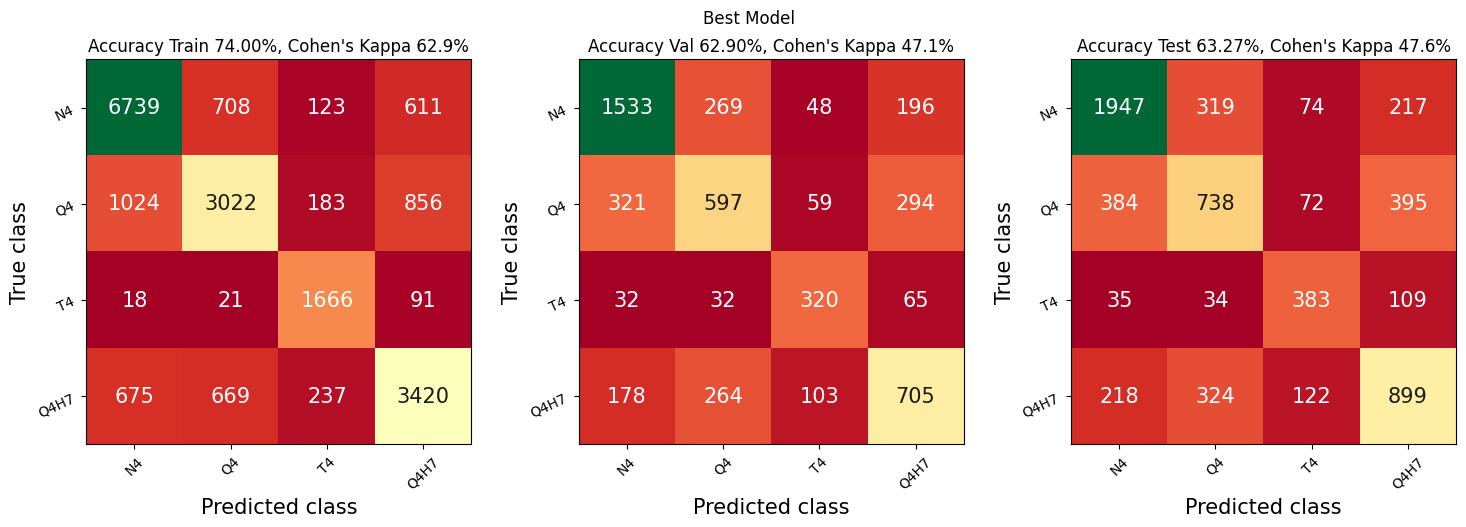

In [4]:
n_epochs = 500
trainer.summary()   
trainer.train(n_epochs)
trainer.test("best") 


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from PycalcAct.dataset import *
from PycalcAct.model import (
    MixedFCTemporalModel)
from PycalcAct.trainer import Trainer
from PycalcAct.calculateCustomAccuracy import calculateCustomAccuracy
from pathlib import Path
from PycalcAct.myCustomCriterion import myCustomCriterion
_ = torch.manual_seed(1234)



# dataFolder = Path(//Hmr_lymph/d/SebastienThis/CalciumPredictions/Ca2-Analysis_McGill/prediction/agAffinity/dataset_mcgill")
dataFolder = Path("D:/Sebastien/Ca2-Analysis_McGill/prediction/agAffinity/datasets/dataset_mcgill")
# dataFolder = Path("D:/Ca2-Analysis_McGill/prediction/agAffinity/datasets/dataset_mcgill")


csv_path=[dataFolder.joinpath("legend.csv"), dataFolder.joinpath("calciumRatio_normalized.csv")] 
csv_pos_path = dataFolder.joinpath("position.csv")

dataset2 = Dataset(
    csv_path = csv_path,
    csv_pos_path=csv_pos_path,  # Optional
    position_to_displacement=True,
    remove_mean=False,
    replace_nan_by_min = True,
    customFilter = False,
    is_regression = True,
	augment_gt = False, # "rand" or "Ca"
)
dataset2.create_new_feature_by_operations(lambda x: np.abs(np.fft.fft(x[:, 0])))

# Setup model
model2 = MixedFCTemporalModel(
    n_classes= 1,
    n_rnn_layers=1,
    rnn_hidden_size=16,
    n_fc_layers=1,
    fc_hidden_size=16,
    temporal_length=dataset2.length_serie,
    input_size=dataset2.features,
    bidirectional=True,
    pooling=None,
    dropout=0.25,
)   

# Setup training
trainer2 = Trainer(
    dataset2,
    model2,
    device="cuda",
    batch_size=400,
    criterion=None,
    is_regression=True,        
    use_class_weights=False,
    regression_bounds_y = torch.Tensor([-12,-10,-9]).to("cuda"),
    regression_bounds_y_pred = torch.Tensor([-12,-10,-9]).to("cuda"),
    store_best="myFScore",
)  

dataset2.summarize()



D:\Sebastien\PycalcActivation\src\PycalcAct\dataset.py:15: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(datapath, header=None)
D:\Sebastien\PycalcActivation\src\PycalcAct\dataset.py:45: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  filter_bool = ((df[col_ageSpe] == 1) & (df[col_activated] == 1) &
d:\Sebastien\Anaconda\envs\calcium\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.25 and num_layers=1
  warnings.warn(


Dataset summary: timepoints 120, features 3
Features:
calciumRatio_normalized Displacement <lambda>


,Total,N4,Q4,T4,Q4H7
Train,25069,10824,7448,5001,1796
Validation,6268,2707,1862,1250,449
Test,7835,3383,2328,1563,561
Total,39172,16914,11638,7814,2806


In [11]:
print(trainer2.dataset.weights)
print(np.unique(trainer2.dataset.y_train))
print(trainer2.metrics)
print(trainer2.dataset.y_train)

tensor([0.5790, 0.8415, 1.2532, 3.4896])
[-12.64206515 -10.13253251  -9.32239305  -8.60906489]
MetricCollection(
  (Accuracy): MulticlassAccuracy()
  (CohenKappa): MulticlassCohenKappa()
  (myFScore): myFScore()
)
[ -9.32239305 -10.13253251 -10.13253251 ... -12.64206515 -12.64206515
 -10.13253251]


╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  myFScore │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│[Epoch,   1/500, 1.10 it/s, ETA  8m] >           31.74 │                     95.76 │       95.76 │

D:\Sebastien\PycalcActivation\src\PycalcAct\myCustomCriterion.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.f_score, dtype=torch.float32)


│             0             │                     31.74 │                     95.76 │
│             1             │                     25.95 │                    694.88 │
│[Epoch,   7/500, 1.48 it/s, ETA  6m] >           24.36 │                           │KeyboardInterrupt


D:\Sebastien\PycalcActivation\src\PycalcAct\myCustomCriterion.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.f_score, dtype=torch.float32)
D:\Sebastien\PycalcActivation\src\PycalcAct\myCustomCriterion.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.f_score, dtype=torch.float32)
D:\Sebastien\PycalcActivation\src\PycalcAct\trainer.py:276: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
D:\Sebastien\PycalcActivation\src\PycalcAct\myCustomCriterion.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requir

{'Accuracy': tensor(0.0728, device='cuda:0'),
 'CohenKappa': tensor(-0.0155, device='cuda:0'),
 'myFScore': tensor(7.0254)}

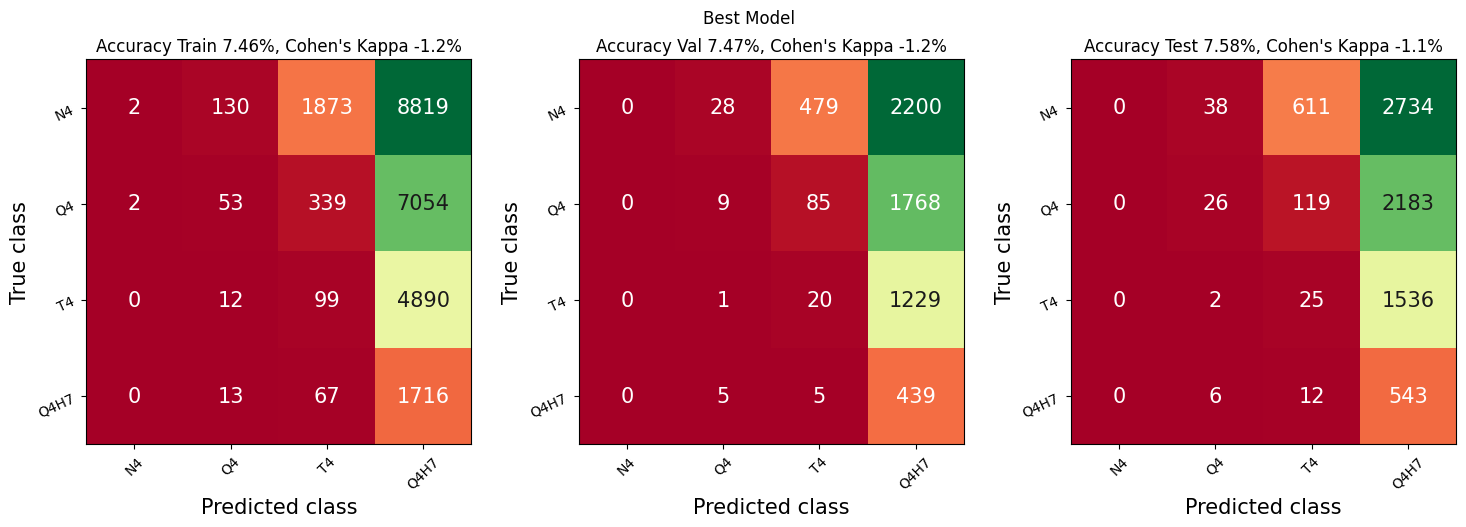

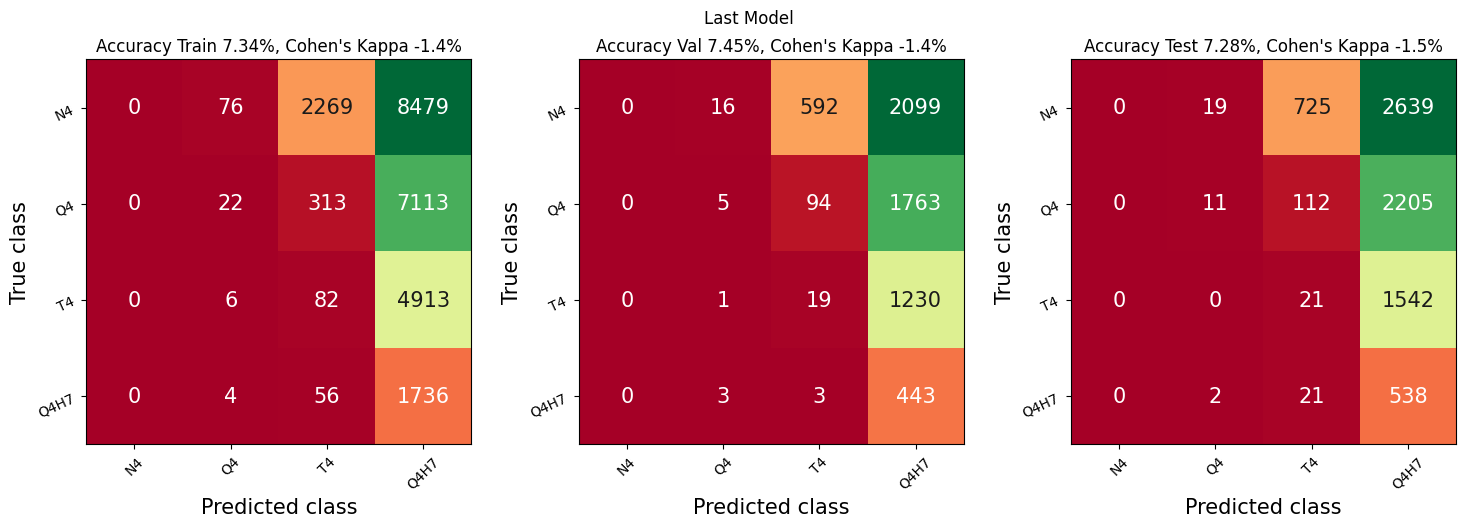

In [12]:
n_epochs = 500
trainer2.train(n_epochs)
trainer2.test("best") 
trainer2.test("last") 

D:\Sebastien\PycalcActivation\src\PycalcAct\myCustomCriterion.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.f_score, dtype=torch.float32)
D:\Sebastien\PycalcActivation\src\PycalcAct\myCustomCriterion.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.f_score, dtype=torch.float32)
D:\Sebastien\PycalcActivation\src\PycalcAct\myCustomCriterion.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.f_score, dtype=torch.float32)


4.128672122955322


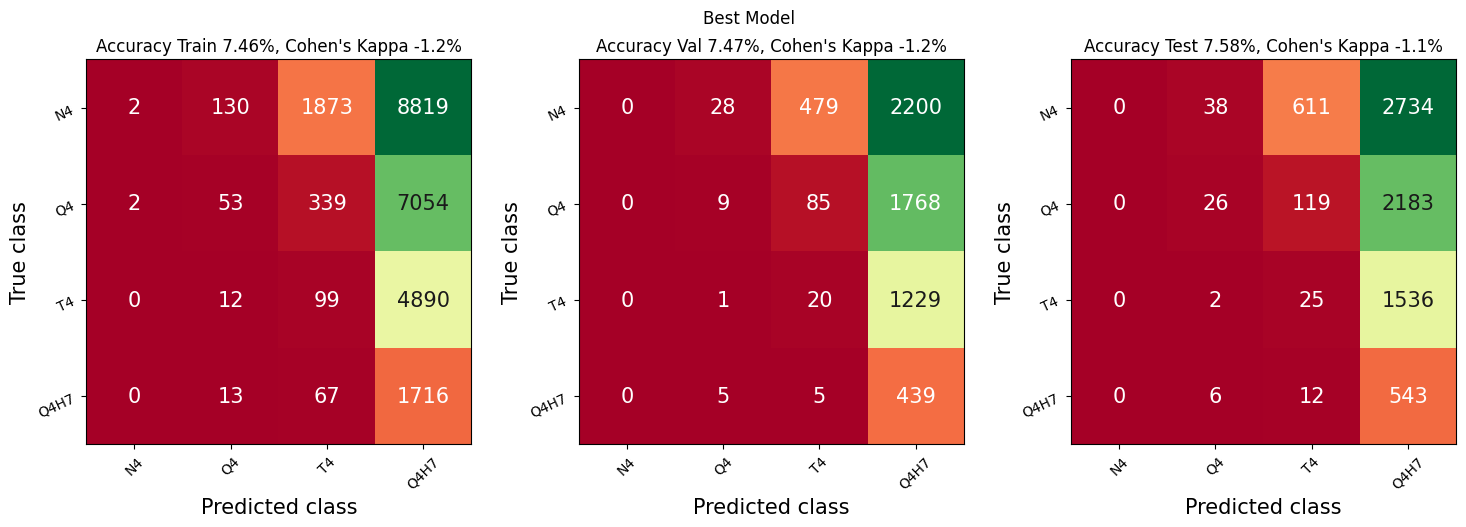

In [17]:
_, metrics = trainer2.test("best", show_confmat=False)
print(metrics['myFScore'].tolist())

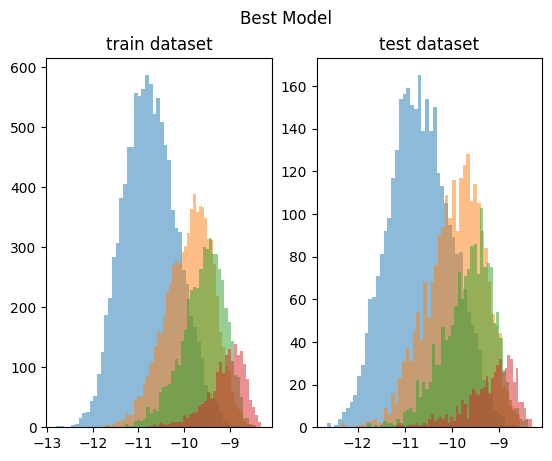

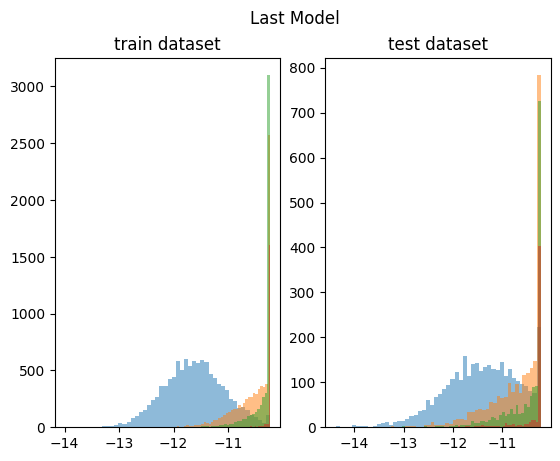

In [6]:
x_test, y_test = trainer2.dataset.test_batch(True, to_cuda=True)
x_train, y_train = trainer2.dataset.train_batch(True, to_cuda=True)

all_classes = np.unique(y_train.cpu().numpy())

trainer2.load_best()
y_pred_train = trainer2.model(torch.Tensor(x_train))
y_pred_test = trainer2.model(torch.Tensor(x_test))
fig, [ax, ax1] = plt.subplots(1,2)
for cls in all_classes:
    ax.hist(y_pred_train[y_train == cls].cpu().detach().numpy(), 50, alpha=0.5, label=f"Class {cls}")
    ax1.hist(y_pred_test[y_test == cls].cpu().detach().numpy(), 50, alpha=0.5, label=f"Class {cls}") 
ax.title.set_text('train dataset')
ax1.title.set_text('test dataset')
fig.suptitle('Best Model') 
plt.show()
trainer2.load_last()
y_pred_train = trainer2.model(torch.Tensor(x_train))
y_pred_test = trainer2.model(torch.Tensor(x_test))
fig, [ax, ax1] = plt.subplots(1,2)
for cls in all_classes:
    ax.hist(y_pred_train[y_train == cls].cpu().detach().numpy(), 50, alpha=0.5, label=f"Class {cls}")
    ax1.hist(y_pred_test[y_test == cls].cpu().detach().numpy(), 50, alpha=0.5, label=f"Class {cls}") 
ax.title.set_text("train dataset")
ax1.title.set_text("test dataset")
fig.suptitle('Last Model') 
plt.draw()

tensor([[-12.0185],
        [-12.2412],
        [-12.1118],
        ...,
        [-11.1182],
        [ -9.8396],
        [-11.0663]], device='cuda:0', grad_fn=<AddmmBackward0>)


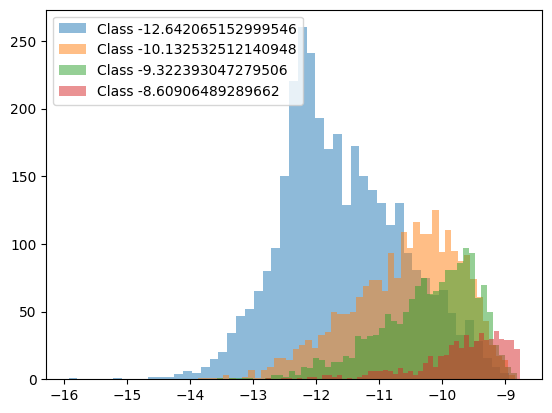

F-statistic: [1426.85282527]


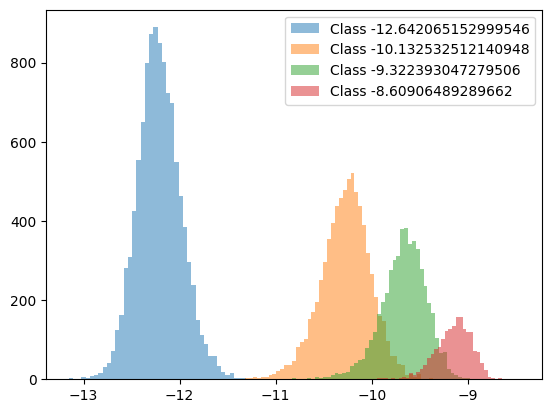

F-statistic: [205786.38394917]


In [5]:
trainer2.load_last()
from scipy.stats import f_oneway
x, y = trainer2.dataset.test_batch(True, to_cuda=True)
y_pred_test = trainer2.model(torch.Tensor(x))
print(y_pred_test)
all_classes = np.unique(y.cpu().numpy())
for cls in all_classes:
    plt.hist(y_pred_test[y == cls].cpu().detach().numpy(), 50, alpha=0.5, label=f"Class {cls}")
plt.legend()
plt.show()

f_statistic_test, p_value_test = f_oneway(y_pred_test[y == all_classes[0]].cpu().detach().numpy(),
                                          y_pred_test[y == all_classes[1]].cpu().detach().numpy(),
                                          y_pred_test[y == all_classes[2]].cpu().detach().numpy(),
                                          y_pred_test[y == all_classes[3]].cpu().detach().numpy())
print(f"F-statistic: {f_statistic_test}")

x, y = trainer2.dataset.train_batch(True, to_cuda=True)
y_pred_train = trainer2.model(torch.Tensor(x))
all_classes = np.unique(y.cpu().numpy())
for cls in all_classes:
    plt.hist(y_pred_train[y == cls].cpu().detach().numpy(), 50, alpha=0.5, label=f"Class {cls}")
plt.legend()
plt.show()

f_statistic_train, p_value_train = f_oneway(y_pred_train[y == all_classes[0]].cpu().detach().numpy(),
                                          y_pred_train[y == all_classes[1]].cpu().detach().numpy(),
                                        y_pred_train[y == all_classes[2]].cpu().detach().numpy(),
                                        y_pred_train[y == all_classes[3]].cpu().detach().numpy())
print(f"F-statistic: {f_statistic_train}")